In [54]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
%matplotlib inline

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory


# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [56]:
df1 = pd.read_csv('dataset_5_amostras.csv')
input_dim = 5
n_features = 5
output_dim = 3
num_epochs = 1000
learning_rate = 0.01
test_size = 0.3
random_state = 42

In [57]:
df1.head()

,massFlow_1,massFlow_2,massFlow_3,massFlow_4,massFlow_5,anomaly
0,0.430400,0.480976,0.454492,0.438224,0.431184,n_amac
1,0.426545,0.210941,0.282410,0.284207,0.281552,n_amac
2,0.281683,0.276073,0.273273,0.273550,0.274200,n_amac
3,0.277646,0.275438,0.269898,0.262658,0.266652,n_amac
4,0.262447,0.260454,0.261663,0.263772,0.259900,n_amac


In [58]:

X = df1.filter(like='massFlow').values  
y = df1['anomaly'].values


In [113]:
scaler = StandardScaler()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)

In [ ]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train_reshaped = X_train.reshape(-1, n_features, 1)  # (n_amostras, 11 timesteps, 1 feature)
X_test_reshaped = X_test.reshape(-1, n_features , 1)


In [ ]:


le = LabelEncoder()
y = le.fit_transform(y)  # converte os rótulos para inteiros

# depois você pode fazer o split normalmente
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# e então converter para tensores
import torch
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)


In [118]:
class NeuralNetworkClassificationModel(nn.Module):
    def __init__(self,input_dim,output_dim):
        super(NeuralNetworkClassificationModel,self).__init__()
        self.input_layer    = nn.Linear(input_dim,128)
        self.hidden_layer1  = nn.Linear(128,64)
        self.output_layer   = nn.Linear(64,output_dim)
        self.relu = nn.ReLU()
    
    
    def forward(self,x):
        out =  self.relu(self.input_layer(x))
        out =  self.relu(self.hidden_layer1(out))
        out =  self.output_layer(out)
        return out

In [119]:
# input_dim = 4 because we have 4 inputs namely sepal_length,sepal_width,petal_length,petal_width
# output_dim = 3 because we have namely 3 categories setosa,versicolor and virginica
input_dim  = input_dim
output_dim = output_dim
model = NeuralNetworkClassificationModel(input_dim,output_dim)

In [120]:
# creating our optimizer and loss function object
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=learning_rate)

In [121]:
def train_network(model,optimizer,criterion,X_train,y_train,X_test,y_test,num_epochs,train_losses,test_losses):
    for epoch in range(num_epochs):
        #clear out the gradients from the last step loss.backward()
        optimizer.zero_grad()
        
        #forward feed
        output_train = model(X_train)

        #calculate the loss
        loss_train = criterion(output_train, y_train)
        
        #backward propagation: calculate gradients
        loss_train.backward()

        #update the weights
        optimizer.step()
        
        output_test = model(X_test)
        loss_test = criterion(output_test,y_test)

        train_losses[epoch] = loss_train.item()
        test_losses[epoch] = loss_test.item()

        if (epoch + 1) % 50 == 0:
            print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {loss_train.item():.4f}, Test Loss: {loss_test.item():.4f}")

In [122]:

train_losses = np.zeros(num_epochs)
test_losses  = np.zeros(num_epochs)
print(X_train.shape)  # Deve ser (n_amostras, 1)
print(X_train[:10])  # Exibe as primeiras 10 amostras

torch.Size([223, 5])
tensor([[-0.3435, -0.4799, -0.1908, -0.2152, -0.0257],
        [ 0.6852,  0.6302,  5.8642,  4.0477,  0.7529],
        [-0.6155, -0.2421, -0.4133, -0.3673, -0.3755],
        [-0.1898,  0.1746,  0.4406,  0.0216, -0.0588],
        [ 0.1535, -0.0074, -0.3063, -0.2369,  0.0977],
        [-0.3832, -0.3794, -0.2462, -0.3376, -0.4864],
        [ 0.1128, -0.1868, -0.0450,  0.0460,  0.3205],
        [-0.3751, -0.0576, -0.2261, -0.3931, -0.3578],
        [ 0.0471,  0.0652, -0.2085,  0.3640, -0.0639],
        [ 0.2679, -0.0544,  0.0121, -0.0909,  0.1501]])


In [123]:
train_losses = np.zeros(num_epochs)
test_losses  = np.zeros(num_epochs)

print(X_train.shape)  # Deve ser (n_amostras, 1)

torch.Size([223, 5])


In [124]:
train_network(model,optimizer,criterion,X_train,y_train,X_test,y_test,num_epochs,train_losses,test_losses)

Epoch 50/1000, Train Loss: 0.6150, Test Loss: 0.9291
Epoch 100/1000, Train Loss: 0.3607, Test Loss: 1.1315
Epoch 150/1000, Train Loss: 0.1952, Test Loss: 1.4180
Epoch 200/1000, Train Loss: 0.0917, Test Loss: 1.6800
Epoch 250/1000, Train Loss: 0.0439, Test Loss: 2.0656
Epoch 300/1000, Train Loss: 0.0225, Test Loss: 2.3684
Epoch 350/1000, Train Loss: 0.0133, Test Loss: 2.6275
Epoch 400/1000, Train Loss: 0.0087, Test Loss: 2.8374
Epoch 450/1000, Train Loss: 0.0061, Test Loss: 3.0149
Epoch 500/1000, Train Loss: 0.0045, Test Loss: 3.1675
Epoch 550/1000, Train Loss: 0.0034, Test Loss: 3.3050
Epoch 600/1000, Train Loss: 0.0027, Test Loss: 3.4319
Epoch 650/1000, Train Loss: 0.0022, Test Loss: 3.5422
Epoch 700/1000, Train Loss: 0.0018, Test Loss: 3.6538
Epoch 750/1000, Train Loss: 0.0015, Test Loss: 3.7486
Epoch 800/1000, Train Loss: 0.0013, Test Loss: 3.8349
Epoch 850/1000, Train Loss: 0.0011, Test Loss: 3.9174
Epoch 900/1000, Train Loss: 0.0010, Test Loss: 3.9991
Epoch 950/1000, Train Loss: 0

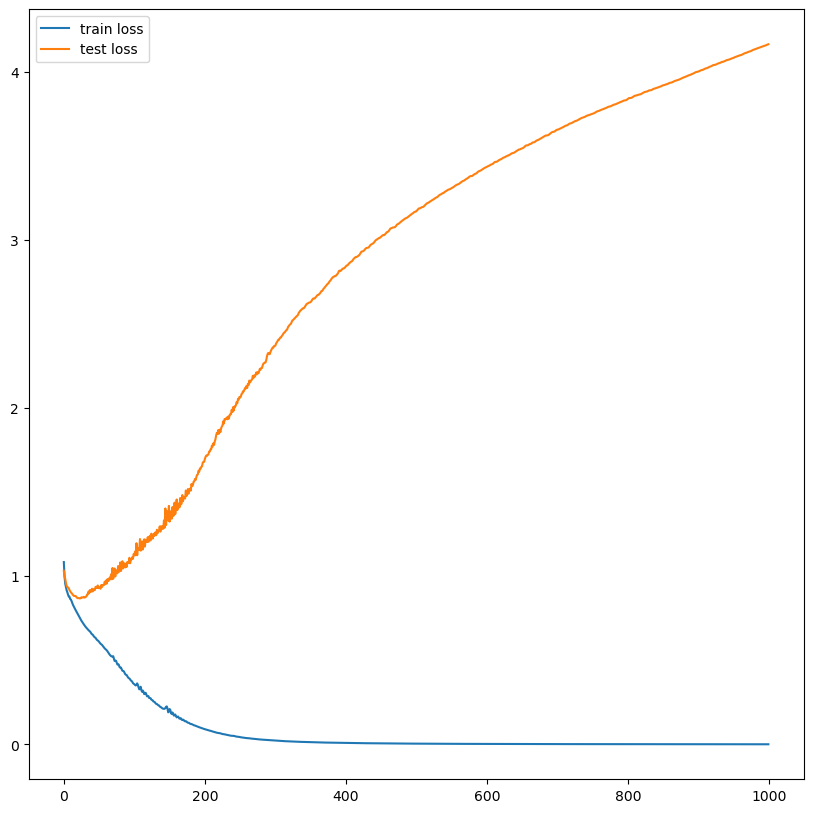

In [125]:
plt.figure(figsize=(10,10))
plt.plot(train_losses, label='train loss')
plt.plot(test_losses, label='test loss')
plt.legend()
plt.show()

In [126]:
predictions_train = []
predictions_test =  []
with torch.no_grad():
    predictions_train = model(X_train)
    predictions_test = model(X_test)

In [127]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

def get_accuracy_multiclass(pred_arr, original_arr, label="Dataset"):
    if len(pred_arr) != len(original_arr):
        return False

    pred_arr = pred_arr.numpy()
    original_arr = original_arr.numpy()

    final_pred = []

    for i in range(len(pred_arr)):
        final_pred.append(np.argmax(pred_arr[i]))

    final_pred = np.array(final_pred)

    count = 0
    for i in range(len(original_arr)):
        if final_pred[i] == original_arr[i]:
            count += 1

    acc = count / len(final_pred)

    print(f"\n{'='*10} {label.upper()} METRICS {'='*10}")
    print("\n> Confusion Matrix:")
    print(confusion_matrix(original_arr, final_pred))
    
    print("\n> Classification Report:")
    print(classification_report(original_arr, final_pred, digits=4))

    print(f"> Accuracy: {acc:.4f}")

    return acc


In [128]:
train_acc = get_accuracy_multiclass(predictions_train, y_train, label="Training Set")
test_acc  = get_accuracy_multiclass(predictions_test, y_test, label="Test Set")



========== TRAINING SET METRICS ==========

> Confusion Matrix:
[[102   0   0]
 [  0  41   0]
 [  0   0  80]]

> Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       102
           1     1.0000    1.0000    1.0000        41
           2     1.0000    1.0000    1.0000        80

    accuracy                         1.0000       223
   macro avg     1.0000    1.0000    1.0000       223
weighted avg     1.0000    1.0000    1.0000       223

> Accuracy: 1.0000

========== TEST SET METRICS ==========

> Confusion Matrix:
[[22  3 13]
 [ 3  6  9]
 [13  9 18]]

> Classification Report:
              precision    recall  f1-score   support

           0     0.5789    0.5789    0.5789        38
           1     0.3333    0.3333    0.3333        18
           2     0.4500    0.4500    0.4500        40

    accuracy                         0.4792        96
   macro avg     0.4541    0.4541    0.4541        96
weighted avg 

Training Accuracy: 100.0
Test Accuracy: 47.917


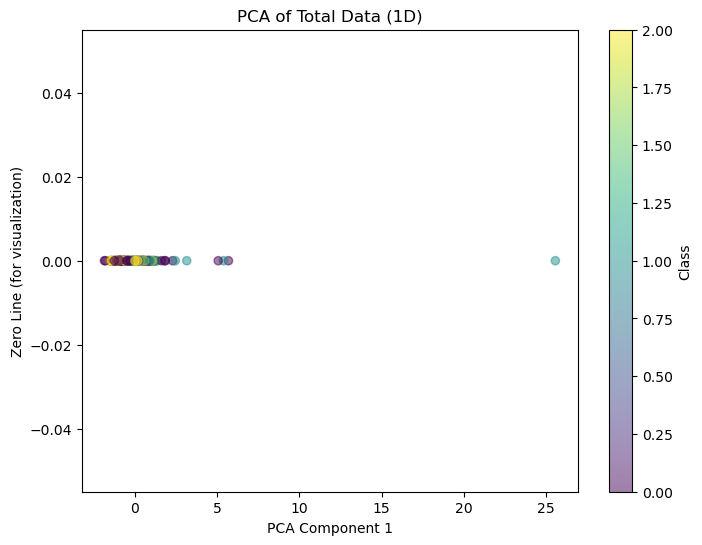

In [129]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Aqui, você já tem o cálculo das acurácias
print(f"Training Accuracy: {round(train_acc*100,3)}")
print(f"Test Accuracy: {round(test_acc*100,3)}")

# Aplicando PCA para reduzir as dimensões para 1 (pois temos 1 feature)
pca = PCA(n_components=1)

# Reduzindo as dimensões dos dados totais (treinamento + teste)
X_total = torch.cat((X_train, X_test), dim=0)  # Concatenando os dados de treino e teste
X_total_pca = pca.fit_transform(X_total)  # Aplicando o PCA no conjunto total

# Plotando os resultados de PCA
plt.figure(figsize=(8, 6))

# Plotando os dados totais
plt.scatter(X_total_pca[:, 0], np.zeros_like(X_total_pca[:, 0]), c=torch.cat((y_train, y_test)), cmap='viridis', alpha=0.5)

# Adicionando títulos e legendas
plt.title('PCA of Total Data (1D)')
plt.xlabel('PCA Component 1')
plt.ylabel('Zero Line (for visualization)')
plt.colorbar(label='Class')

plt.show()

# PCA(n_components=1): Reduz os dados para apenas 1 componente principal.

# torch.cat((X_train, X_test), dim=0): Combina os dados de treino e teste em um único array/tensor (X_total).

# fit_transform(X_total): Calcula o PCA e transforma os dados para o novo espaço 1D.

# Eixo X: Valores da componente principal 1 (X_total_pca[:, 0]).

# Eixo Y: Uma linha de zeros (np.zeros_like), apenas para visualização (já que os dados são 1D).

# Cores: Definidas pelas classes (y_train e y_test concatenadas), usando o colormap viridis.

# Distribuição 1D: Mostra como as amostras se distribuem ao longo da única componente principal.

# Separação de Classes:

# Se as classes (cores) estiverem bem separadas ao longo do eixo X, a componente 1 é discriminativa.

# Se estiverem misturadas, a feature original não separa bem as classes.

# PCA(n_components=1) cria uma nova componente que é uma combinação linear de time e massFlow.

# A fórmula seria algo como:
# PC1 = a * time + b * massFlow
# (onde a e b são os "loadings" calculados pelo PCA)



In [162]:
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.decomposition import PCA

# # 1. Preparar os dados
# X = df1[['time', 'massFlow']].values  # Features (time e massFlow)
# y = df1['anomaly'].values             # Rótulos (anomaly)

# # 2. Aplicar PCA para reduzir para 2 componentes (para visualização)
# pca = PCA(n_components=2)
# X_pca = pca.fit_transform(X)

# # 3. Criar um mapa de cores para as classes (assumindo que 'n_amac' é a classe normal)
# classes = np.unique(y)
# colors = {'n_amac': 'blue', 'n_sab': 'red', 'amac': 'green'}  # Defina cores para cada classe

# # 4. Plotar os resultados
# plt.figure(figsize=(10, 6))

# # Plotar cada classe separadamente para legenda clara
# for cls in classes:
#     mask = (y == cls)
#     plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
#                c=colors.get(cls, 'gray'), 
#                label=cls, 
#                alpha=0.7)

# # Adicionar títulos e legendas
# plt.title('PCA of Time vs. MassFlow (2D)')
# plt.xlabel('Principal Component 1 (PC1)')
# plt.ylabel('Principal Component 2 (PC2)')
# plt.legend()
# plt.grid(True)

# # Mostrar a variância explicada por cada componente
# explained_var = pca.explained_variance_ratio_
# print(f"Variância explicada: PC1 = {explained_var[0]:.2%}, PC2 = {explained_var[1]:.2%}")

# plt.show()


# # X: Extrai as colunas 'time' e 'massFlow' do DataFrame df1 e converte para um array NumPy

# # y: Extrai a coluna 'anomaly' (que contém as classes/labels) como um array NumPy

# # Eixo X: Primeiro componente principal (PC1)

# # Eixo Y: Segundo componente principal (PC2)

# # Cores: Classes diferentes (n_amac, n_sab, amac)

# # Pontos: Cada ponto representa uma observação no novo espaço 2D